 EDA — Walmart Sales Forecast



 1. Configuración inicial e imports

In [ ]:
import sys
sys.path.insert(0, '..')  # para que encuentre el paquete walmart_forecast

from walmart_sales_forecast.analisis_eda import AnalisisExploratorio
from walmart_sales_forecast.dataset import DataLoader, DataIntegrador

print('Imports OK')

 2. Cargar y combinar los 4 CSV

In [2]:
cargador = DataLoader()
integrador = DataIntegrador()
analisis = AnalisisExploratorio()

train = cargador.cargar_train()
test = cargador.cargar_test()
features = cargador.cargar_features()
stores = cargador.cargar_stores()

dataset = integrador.combinar_datasets(train, features, stores)
print('Dataset combinado:', dataset.shape)

Dataset combinado: (421570, 16)


 3. EDA individual: resumen general de cada CSV


In [3]:
analisis.ejecutarEdaBasico(train, 'train')


RESUMEN: train
Filas: 421,570 | Columnas: 5

Tipos de datos:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object

Rango de fechas: 2010-02-05 00:00:00 a 2012-10-26 00:00:00

Valores nulos en train:
  Sin valores nulos.

Estadísticas descriptivas de train:
                 count unique    top    freq                           mean  \
Store         421570.0    NaN    NaN     NaN                      22.200546   
Dept          421570.0    NaN    NaN     NaN                      44.260317   
Date            421570    NaN    NaN     NaN  2011-06-18 08:30:31.963375104   
Weekly_Sales  421570.0    NaN    NaN     NaN                   15981.258123   
IsHoliday       421570      2  False  391909                            NaN   

                              min                  25%                  50%  \
Store                         1.0                 11.0                 2

In [4]:
analisis.ejecutarEdaBasico(test, 'test')


RESUMEN: test
Filas: 115,064 | Columnas: 4

Tipos de datos:
Store                 int64
Dept                  int64
Date         datetime64[ns]
IsHoliday              bool
dtype: object

Rango de fechas: 2012-11-02 00:00:00 a 2013-07-26 00:00:00

Valores nulos en test:
  Sin valores nulos.

Estadísticas descriptivas de test:
              count unique    top    freq                           mean  \
Store      115064.0    NaN    NaN     NaN                      22.238207   
Dept       115064.0    NaN    NaN     NaN                      44.339524   
Date         115064    NaN    NaN     NaN  2013-03-14 14:39:41.311270144   
IsHoliday    115064      2  False  106136                            NaN   

                           min                  25%                  50%  \
Store                      1.0                 11.0                 22.0   
Dept                       1.0                 18.0                 37.0   
Date       2012-11-02 00:00:00  2013-01-04 00:00:00  2013-03-15

In [5]:
analisis.ejecutarEdaBasico(features, 'features')


RESUMEN: features
Filas: 8,190 | Columnas: 12

Tipos de datos:
Store                    int64
Date            datetime64[ns]
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
IsHoliday                 bool
dtype: object

Rango de fechas: 2010-02-05 00:00:00 a 2013-07-26 00:00:00

Valores nulos en features:
              nulos  porcentaje_%
MarkDown2      5269         64.33
MarkDown4      4726         57.70
MarkDown3      4577         55.89
MarkDown1      4158         50.77
MarkDown5      4140         50.55
CPI             585          7.14
Unemployment    585          7.14

Estadísticas descriptivas de features:
               count unique    top  freq                 mean  \
Store         8190.0    NaN    NaN   NaN                 23.0   
Date            8190

In [6]:
analisis.ejecutarEdaBasico(stores, 'stores')


RESUMEN: stores
Filas: 45 | Columnas: 3

Tipos de datos:
Store     int64
Type     object
Size      int64
dtype: object

Valores nulos en stores:
  Sin valores nulos.

Estadísticas descriptivas de stores:
      count unique  top freq      mean           std      min      25%  \
Store  45.0    NaN  NaN  NaN      23.0     13.133926      1.0     12.0   
Type     45      3    A   22       NaN           NaN      NaN      NaN   
Size   45.0    NaN  NaN  NaN  130287.6  63825.271991  34875.0  70713.0   

            50%       75%       max  
Store      23.0      34.0      45.0  
Type        NaN       NaN       NaN  
Size   126512.0  202307.0  219622.0  


 4. Duplicados y validación de formato

In [7]:
analisis.detectarDuplicados(train, columnasClave=['Store', 'Dept', 'Date'])

Filas duplicadas encontradas: 0 de 421570 (0.00%)


,Store,Dept,Date,Weekly_Sales,IsHoliday


In [8]:
tipos_esperados = {
    'Store': 'int64',
    'Dept': 'int64',
    'Weekly_Sales': 'float64',
    'IsHoliday': 'bool',
}
analisis.validarFormato(train, tipos_esperados)

✓ Todos los formatos son correctos


True

 5. Outliers en Weekly_Sales

In [9]:
outliers = analisis.detectarOutliersIQR(dataset, 'Weekly_Sales')
outliers.head()

Outliers detectados en Weekly_Sales: 35521 de 421570 filas (8.43%)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
8,1,1,2010-04-02,57258.43,False,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,A,151315
46,1,1,2010-12-24,55931.23,False,52.33,2.886,NaN,NaN,NaN,NaN,NaN,211.405122,7.838,A,151315
63,1,1,2011-04-22,50510.31,False,72.99,3.807,NaN,NaN,NaN,NaN,NaN,215.459905,7.682,A,151315
106,1,1,2012-02-17,54060.10,False,45.32,3.510,9873.33,11062.27,9.80,8409.31,3402.66,220.425759,7.348,A,151315
113,1,1,2012-04-06,57592.12,False,70.43,3.891,10121.97,NaN,77.98,3750.59,4510.72,221.435611,7.143,A,151315


 6. Gráficos del dataset combinado

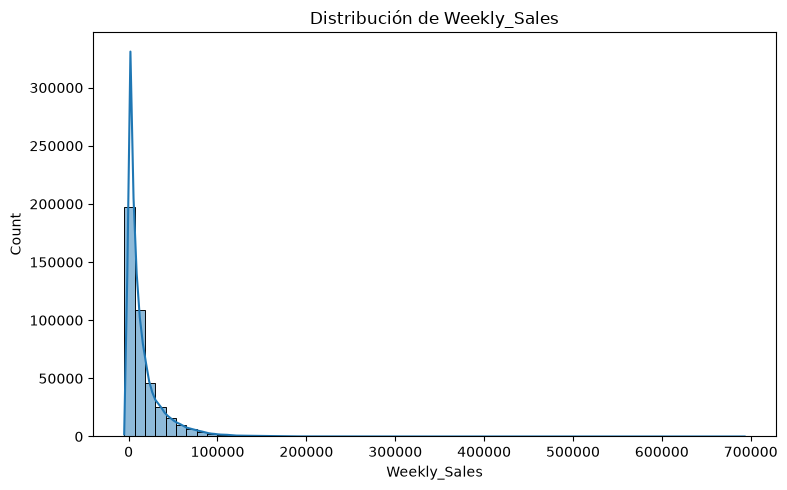

In [10]:
analisis.graficarDistribucionVentas(dataset)

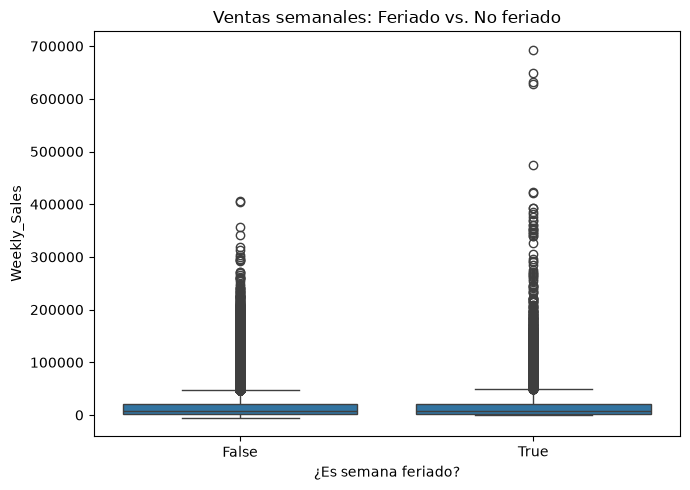

In [11]:
analisis.graficarVentasPorFeriado(dataset)

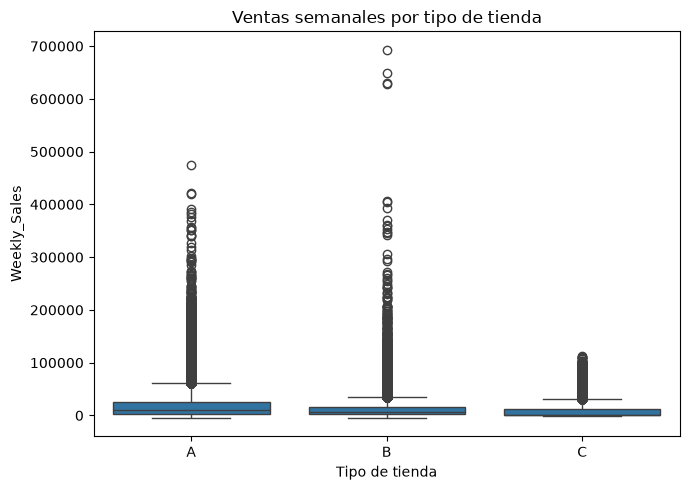

In [12]:
analisis.graficarVentasPorTipoTienda(dataset)

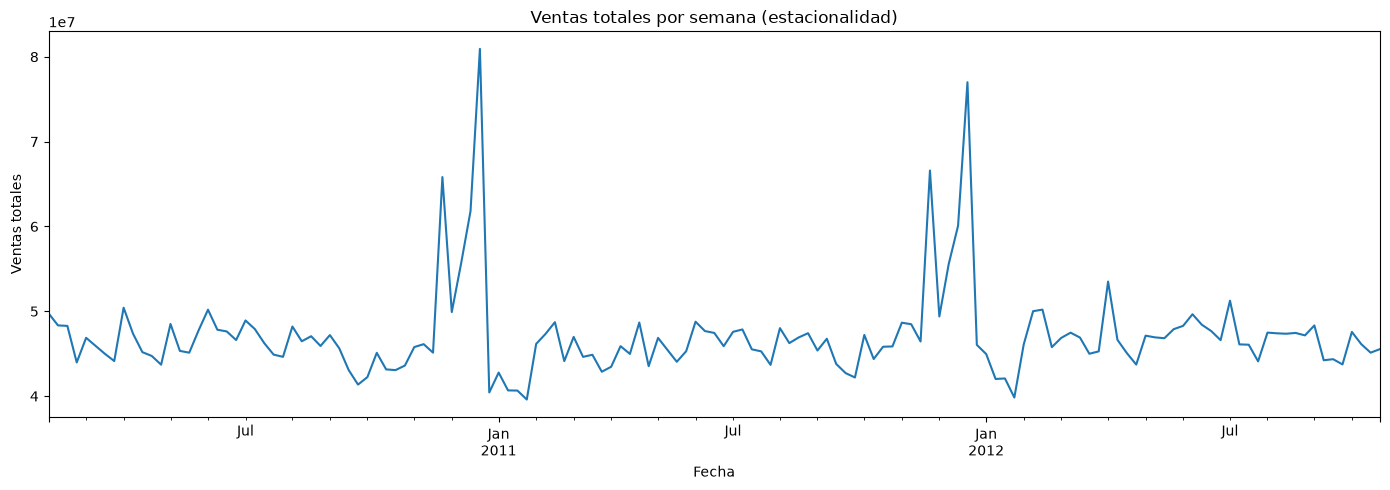

In [13]:
analisis.graficarEstacionalidad(dataset)

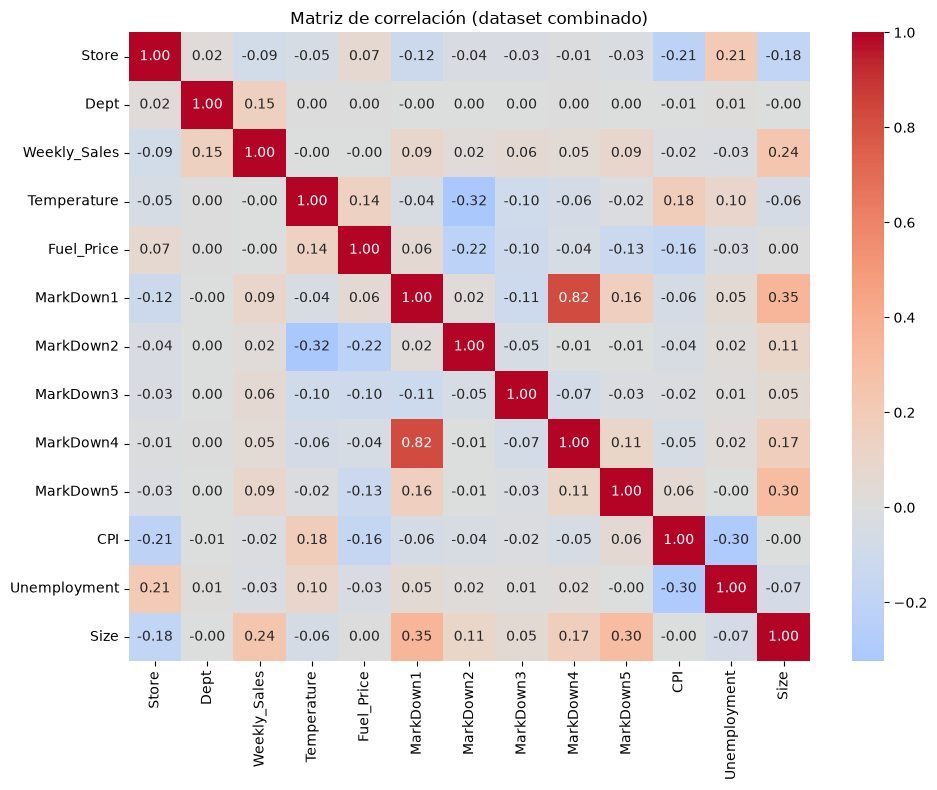

In [14]:
analisis.graficarCorrelacion(dataset)